In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    KFold, cross_val_score, cross_val_predict,
    GridSearchCV, RandomizedSearchCV, learning_curve
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import randint, uniform

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
print('Libraries loaded ')

Libraries loaded ✅


In [9]:
train = pd.read_csv('/kaggle/input/competitions/project-1-laptop-price-prediction/train_data.csv')
test  = pd.read_csv('/kaggle/input/competitions/project-1-laptop-price-prediction/test_data.csv')
print(f'Train: {train.shape} | Test: {test.shape}')
train.head()

Train: (881, 16) | Test: (394, 15)


,id,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [10]:
train.describe()

,id,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro)
count,881.00000,881.000000,881.000000,881.000000,881.000000,881.000000
mean,441.00000,15.085017,2.281839,8.522134,2.049714,1110.183235
std,254.46709,1.396360,0.527334,4.921176,0.657077,711.526332
min,1.00000,10.100000,0.900000,2.000000,0.690000,191.900000
25%,221.00000,14.000000,1.800000,4.000000,1.580000,589.000000
50%,441.00000,15.600000,2.500000,8.000000,2.040000,945.000000
75%,661.00000,15.600000,2.700000,8.000000,2.300000,1426.660000
max,881.00000,18.400000,3.600000,32.000000,4.700000,6099.000000


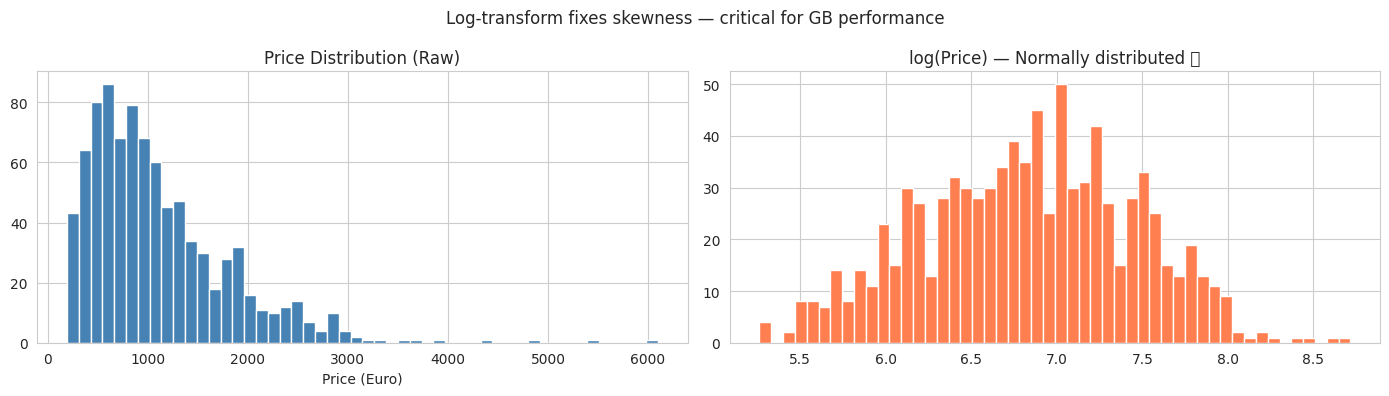

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(train['Price (Euro)'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)'); axes[0].set_xlabel('Price (Euro)')
axes[1].hist(np.log1p(train['Price (Euro)']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('log(Price) — Normally distributed ')
plt.suptitle('Log-transform fixes skewness — critical for GB performance', fontsize=12)
plt.tight_layout(); plt.show()

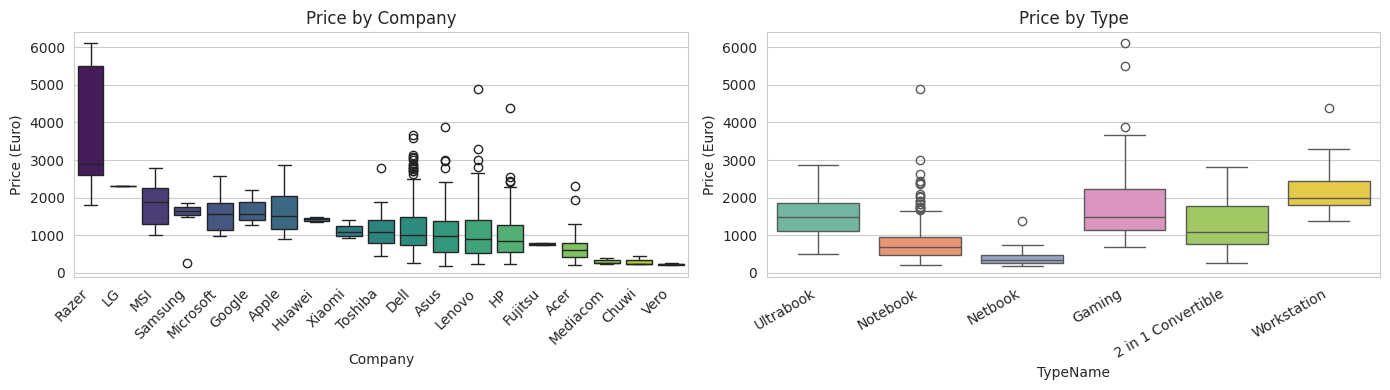

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
order = train.groupby('Company')['Price (Euro)'].median().sort_values(ascending=False).index
sns.boxplot(data=train, x='Company', y='Price (Euro)', order=order, palette='viridis', ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_title('Price by Company')
sns.boxplot(data=train, x='TypeName', y='Price (Euro)', palette='Set2', ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_title('Price by Type')
plt.tight_layout(); plt.show()

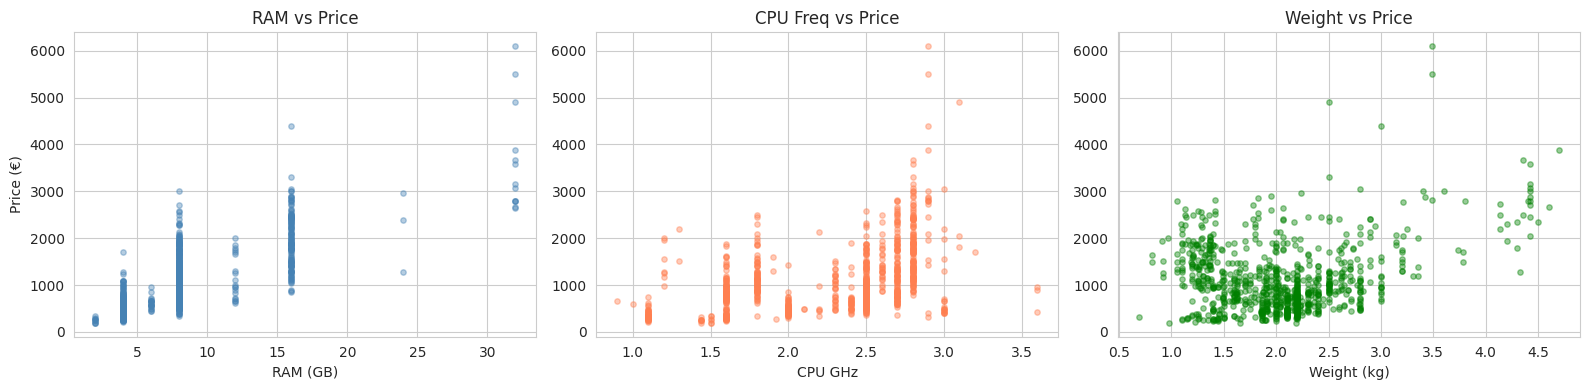

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(train['RAM (GB)'], train['Price (Euro)'], alpha=0.4, color='steelblue', s=15)
axes[0].set_xlabel('RAM (GB)'); axes[0].set_ylabel('Price (€)'); axes[0].set_title('RAM vs Price')
axes[1].scatter(train['CPU_Frequency (GHz)'], train['Price (Euro)'], alpha=0.4, color='coral', s=15)
axes[1].set_xlabel('CPU GHz'); axes[1].set_title('CPU Freq vs Price')
axes[2].scatter(train['Weight (kg)'], train['Price (Euro)'], alpha=0.4, color='green', s=15)
axes[2].set_xlabel('Weight (kg)'); axes[2].set_title('Weight vs Price')
plt.tight_layout(); plt.show()

In [14]:
def parse_screen(x):
    x = str(x)
    touch   = 1 if 'Touchscreen' in x else 0
    ips     = 1 if 'IPS' in x else 0
    retina  = 1 if 'Retina'  in x else 0
    quad_hd = 1 if 'Quad'    in x else 0
    four_k  = 1 if ('4K' in x or '3840' in x) else 0
    full_hd = 1 if '1920x1080' in x else 0
    hd_720  = 1 if '1366x768'  in x else 0
    m = re.findall(r'(\d+)x(\d+)', x)
    w, h = (int(m[0][0]), int(m[0][1])) if m else (0, 0)
    return touch, ips, retina, quad_hd, four_k, full_hd, hd_720, w*h, w, h

def parse_memory(x):
    x = str(x)
    ssd    = sum((int(m) if v=='GB' else int(m)*1024) for m,v in re.findall(r'(\d+)(GB|TB) SSD', x))
    hdd    = sum((int(m) if v=='GB' else int(m)*1024) for m,v in re.findall(r'(\d+)(GB|TB) HDD', x))
    flash  = sum((int(m) if v=='GB' else int(m)*1024) for m,v in re.findall(r'(\d+)(GB|TB) Flash', x))
    hybrid = sum((int(m) if v=='GB' else int(m)*1024) for m,v in re.findall(r'(\d+)(GB|TB) Hybrid', x))
    emmc   = sum((int(m) if v=='GB' else int(m)*1024) for m,v in re.findall(r'(\d+)(GB|TB) eMMC', x))
    n_drives = len(re.findall(r'\+', x)) + 1
    return ssd, hdd, flash+hybrid+emmc, n_drives

def get_cpu_tier(x):
    x = str(x)
    if 'i9' in x or 'Xeon' in x:          return 6
    if 'i7' in x:                          return 5
    if 'i5' in x:                          return 4
    if 'i3' in x:                          return 3
    if 'Ryzen 7' in x or 'Ryzen 5' in x:  return 4
    if 'Ryzen 3' in x:                     return 3
    if 'Celeron' in x or 'Pentium' in x or 'Atom' in x: return 1
    return 2

def get_cpu_gen(x):
    m = re.findall(r'i[3579]-(\d)(\d{3})', str(x))
    return int(m[0][0]) if m else 0

def get_gpu_tier(x):
    x = str(x).lower()
    if any(k in x for k in ['rtx 20','rtx 30','quadro']):           return 6
    if any(k in x for k in ['gtx 1080','gtx 1070','rx 580','vega']): return 5
    if any(k in x for k in ['gtx 1060','1050 ti','rx 570']):         return 4
    if any(k in x for k in ['gtx 1050','940','950','960','mx','gt ','radeon r9','radeon r7']): return 3
    if any(k in x for k in ['gt 9','gt 8','radeon r5']):             return 2
    if any(k in x for k in ['intel','uhd','hd graphics','iris']):    return 1
    return 2

print('Parsing helpers defined ')

Parsing helpers defined ✅


In [15]:
def engineer(df):
    df = df.copy()

    sc = df['ScreenResolution'].apply(lambda x: pd.Series(parse_screen(x)))
    sc.columns = ['Touchscreen','IPS','Retina','QuadHD','FourK',
                  'FullHD','HD720','Resolution_px','Res_W','Res_H']
    df = pd.concat([df, sc], axis=1)

    mm = df['Memory'].apply(lambda x: pd.Series(parse_memory(x)))
    mm.columns = ['SSD_GB','HDD_GB','Flash_GB','N_Drives']
    df = pd.concat([df, mm], axis=1)

    df['Total_Storage']   = df['SSD_GB'] + df['HDD_GB'] + df['Flash_GB']
    df['Has_SSD']         = (df['SSD_GB']>0).astype(int)
    df['Has_HDD']         = (df['HDD_GB']>0).astype(int)
    df['Only_SSD']        = ((df['SSD_GB']>0)&(df['HDD_GB']==0)).astype(int)
    df['Hybrid_Storage']  = ((df['SSD_GB']>0)&(df['HDD_GB']>0)).astype(int)
    df['SSD_ratio']       = df['SSD_GB'] / (df['Total_Storage'] + 1)
    df['SSD_sq']          = df['SSD_GB'] ** 2
    df['SSD_sqrt']        = np.sqrt(df['SSD_GB'])          
    df['SSD_cbrt']        = np.cbrt(df['SSD_GB'])          
    df['log_SSD']         = np.log1p(df['SSD_GB'])
    df['log_HDD']         = np.log1p(df['HDD_GB'])
    df['log_Storage']     = np.log1p(df['Total_Storage'])
    df['sqrt_Storage']    = np.sqrt(df['Total_Storage'])   
    df['Storage_per_kg']  = df['Total_Storage'] / (df['Weight (kg)'] + 0.1)

    df['PPI']             = df['Resolution_px'] / (df['Inches'] ** 2)
    df['Aspect_ratio']    = df['Res_W'] / (df['Res_H'] + 1)
    df['Screen_area']     = df['Inches'] ** 2
    df['log_Res']         = np.log1p(df['Resolution_px'])
    df['log_PPI']         = np.log1p(df['PPI'])
    df['sqrt_PPI']        = np.sqrt(df['PPI'])             
    df['PPI_sq']          = df['PPI'] ** 2

    df['CPU_Tier']        = df['CPU_Type'].apply(get_cpu_tier)   
    df['CPU_Gen']         = df['CPU_Type'].apply(get_cpu_gen)    
    df['CPU_Score']       = df['CPU_Frequency (GHz)'] * df['RAM (GB)']
    df['CPU_Tier_Score']  = df['CPU_Tier'] * df['CPU_Frequency (GHz)']
    df['CPU_per_kg']      = df['CPU_Frequency (GHz)'] / (df['Weight (kg)'] + 0.1)
    df['log_CPU_Score']   = np.log1p(df['CPU_Score'])
    df['sqrt_CPU_Score']  = np.sqrt(df['CPU_Score'])       
    df['log_CPU_Tier_Score'] = np.log1p(df['CPU_Tier_Score'])

    df['log_RAM']         = np.log1p(df['RAM (GB)'])
    df['sqrt_RAM']        = np.sqrt(df['RAM (GB)'])        
    df['RAM_sq']          = df['RAM (GB)'] ** 2
    df['RAM_cbrt']        = np.cbrt(df['RAM (GB)'])        
    df['RAM_per_kg']      = df['RAM (GB)'] / (df['Weight (kg)'] + 0.1)

    df['GPU_Tier']        = df['GPU_Type'].apply(get_gpu_tier)   
    df['GPU_Tier_sq']     = df['GPU_Tier'] ** 2
    df['log_GPU_Tier']    = np.log1p(df['GPU_Tier'])

    df['log_Weight']      = np.log1p(df['Weight (kg)'])
    df['inv_Weight']      = 1.0 / (df['Weight (kg)'] + 0.1)  

    df['Is_Premium']      = df['Company'].isin(['Apple','Razer','MSI']).astype(int)
    df['Is_Budget']       = df['Company'].isin(['Mediacom','Vero','Chuwi']).astype(int)
    df['Is_Gaming']       = df['TypeName'].str.contains('Gaming',na=False).astype(int)
    df['Is_Workstation']  = df['TypeName'].str.contains('Workstation',na=False).astype(int)
    df['Is_Ultrabook']    = df['TypeName'].str.contains('Ultrabook',na=False).astype(int)

    df['RAM_x_SSD']       = df['RAM (GB)'] * df['SSD_GB']
    df['RAM_x_CPU']       = df['RAM (GB)'] * df['CPU_Frequency (GHz)']
    df['RAM_x_GPU']       = df['RAM (GB)'] * df['GPU_Tier']
    df['RAM_x_IPS']       = df['RAM (GB)'] * df['IPS']
    df['RAM_x_CPUTier']   = df['RAM (GB)'] * df['CPU_Tier']
    df['CPU_x_SSD']       = df['CPU_Frequency (GHz)'] * df['SSD_GB']
    df['CPU_x_GPU']       = df['CPU_Frequency (GHz)'] * df['GPU_Tier']
    df['SSD_x_GPU']       = df['SSD_GB'] * df['GPU_Tier']
    df['SSD_x_IPS']       = df['SSD_GB'] * df['IPS']
    df['GPU_x_IPS']       = df['GPU_Tier'] * df['IPS']
    df['PPI_x_RAM']       = df['PPI'] * df['RAM (GB)']
    df['Weight_x_RAM']    = df['Weight (kg)'] * df['RAM (GB)']
    df['Premium_x_RAM']   = df['Is_Premium'] * df['RAM (GB)']
    df['Premium_x_SSD']   = df['Is_Premium'] * df['SSD_GB']
    df['Premium_x_GPU']   = df['Is_Premium'] * df['GPU_Tier']
    df['Gaming_x_GPU']    = df['Is_Gaming'] * df['GPU_Tier']
    df['Gaming_x_RAM']    = df['Is_Gaming'] * df['RAM (GB)']

    df['log_RAM_x_SSD']   = np.log1p(df['RAM_x_SSD'])
    df['log_RAM_x_CPU']   = np.log1p(df['RAM_x_CPU'])
    df['log_CPU_x_SSD']   = np.log1p(df['CPU_x_SSD'])

    df['RAM_x_SSD_x_CPU'] = df['RAM (GB)'] * df['SSD_GB'] * df['CPU_Frequency (GHz)']
    df['RAM_x_SSD_x_GPU'] = df['RAM (GB)'] * df['SSD_GB'] * df['GPU_Tier']
    df['CPU_x_GPU_x_RAM'] = df['CPU_Frequency (GHz)'] * df['GPU_Tier'] * df['RAM (GB)']
    df['log_triple']      = np.log1p(df['RAM_x_SSD_x_CPU'])  

    return df

train = engineer(train)
test  = engineer(test)
print('Feature engineering done  — 99 total features')

Feature engineering done ✅ — 99 total features


In [16]:
global_mean = np.log1p(train['Price (Euro)']).mean()
smoothing_params = [('Company',10),('GPU_Type',5),('CPU_Type',5),
                    ('TypeName',10),('OpSys',15),('CPU_Company',10)]

for col, s in smoothing_params:
    stats = train.groupby(col)['Price (Euro)'].agg(['mean','count'])
    stats['enc'] = (
        np.log1p(stats['mean']) * stats['count'] + global_mean * s
    ) / (stats['count'] + s)
    train[col+'_te'] = train[col].map(stats['enc']).fillna(global_mean)
    test[col+'_te']  = test[col].map(stats['enc']).fillna(global_mean)

print('Target encoding done  — 6 columns (Company, GPU, CPU, Type, OpSys, CPU_Company)')

Target encoding done ✅ — 6 columns (Company, GPU, CPU, Type, OpSys, CPU_Company)


In [17]:
cat_cols = ['Company','TypeName','CPU_Company','CPU_Type','GPU_Company','GPU_Type','OpSys']
for c in cat_cols:
    le = LabelEncoder()
    le.fit(pd.concat([train[c], test[c]]).astype(str))
    train[c+'_enc'] = le.transform(train[c].astype(str))
    test[c+'_enc']  = le.transform(test[c].astype(str))

feature_cols = [
    'Inches','RAM (GB)','CPU_Frequency (GHz)','Weight (kg)',
    'Touchscreen','IPS','Retina','QuadHD','FourK','FullHD','HD720',
    'Resolution_px','Res_W','Res_H','PPI','Aspect_ratio','Screen_area',
    'log_Res','log_PPI','sqrt_PPI','PPI_sq',
    'SSD_GB','HDD_GB','Flash_GB','N_Drives','Total_Storage',
    'Has_SSD','Has_HDD','Only_SSD','Hybrid_Storage','SSD_ratio',
    'SSD_sq','SSD_sqrt','SSD_cbrt','log_SSD','log_HDD','log_Storage','sqrt_Storage',
    'Storage_per_kg',
    'CPU_Tier','CPU_Gen','CPU_Score','CPU_Tier_Score','CPU_per_kg',
    'log_CPU_Score','sqrt_CPU_Score','log_CPU_Tier_Score',
    'log_RAM','sqrt_RAM','RAM_sq','RAM_cbrt','RAM_per_kg',
    'GPU_Tier','GPU_Tier_sq','log_GPU_Tier',
    'log_Weight','inv_Weight',
    'Is_Premium','Is_Budget','Is_Gaming','Is_Workstation','Is_Ultrabook',
    'RAM_x_SSD','RAM_x_CPU','RAM_x_GPU','RAM_x_IPS','RAM_x_CPUTier',
    'CPU_x_SSD','CPU_x_GPU','SSD_x_GPU','SSD_x_IPS','GPU_x_IPS',
    'PPI_x_RAM','Weight_x_RAM',
    'Premium_x_RAM','Premium_x_SSD','Premium_x_GPU',
    'Gaming_x_GPU','Gaming_x_RAM',
    'log_RAM_x_SSD','log_RAM_x_CPU','log_CPU_x_SSD',
    'RAM_x_SSD_x_CPU','RAM_x_SSD_x_GPU','CPU_x_GPU_x_RAM','log_triple',
    'Company_te','GPU_Type_te','CPU_Type_te','TypeName_te','OpSys_te','CPU_Company_te',
    'Company_enc','TypeName_enc','CPU_Company_enc','CPU_Type_enc',
    'GPU_Company_enc','GPU_Type_enc','OpSys_enc'
]

X      = train[feature_cols].values.astype(float)
y_raw  = train['Price (Euro)'].values
y_log  = np.log1p(y_raw)      
X_test = test[feature_cols].values.astype(float)

scaler   = StandardScaler()
Xs       = scaler.fit_transform(X)
Xs_test  = scaler.transform(X_test)

kf = KFold(n_splits=10, shuffle=True, random_state=42) 
print(f'Total features: {len(feature_cols)} | Train: {X.shape[0]} | Test: {X_test.shape[0]}')

Total features: 99 | Train: 881 | Test: 394


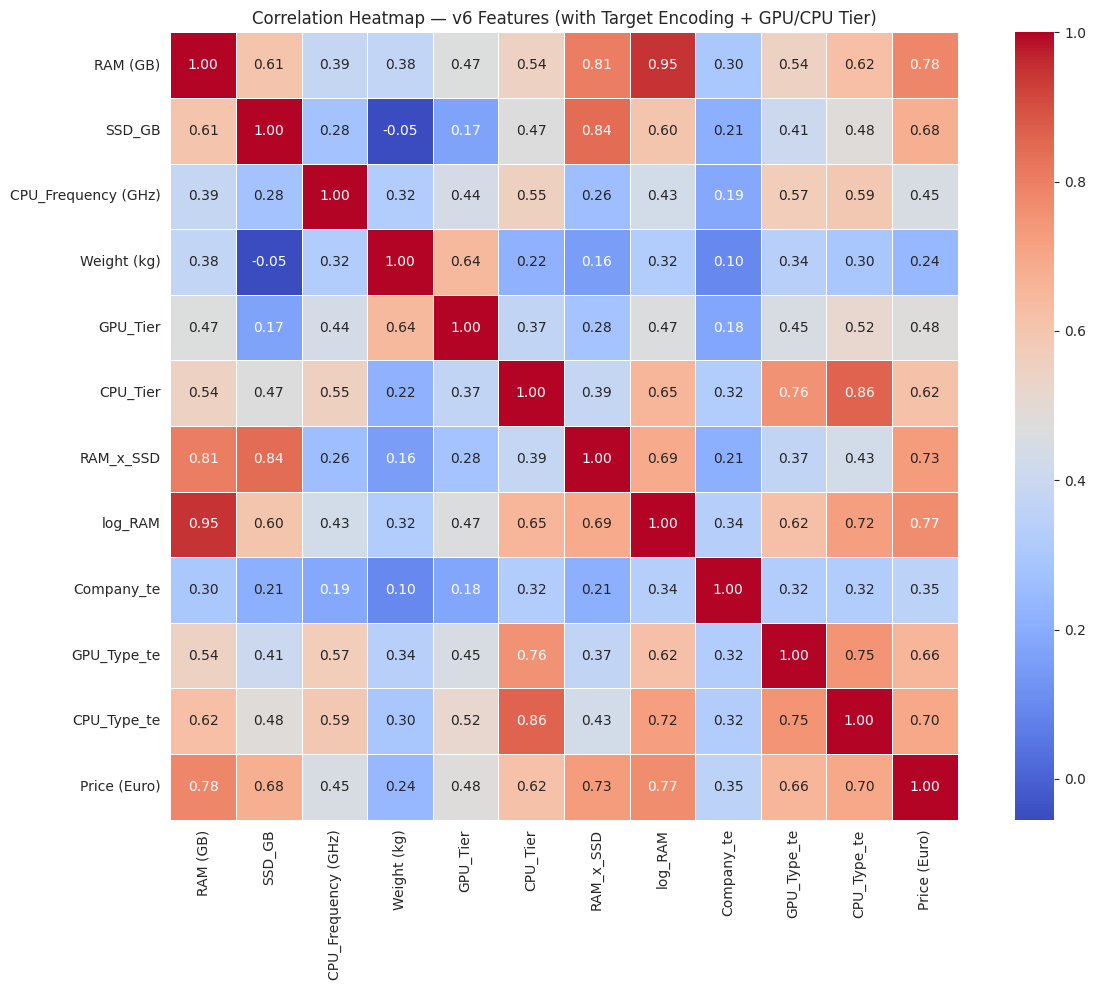

In [18]:
key = ['RAM (GB)','SSD_GB','CPU_Frequency (GHz)','Weight (kg)',
       'GPU_Tier','CPU_Tier','RAM_x_SSD','log_RAM',
       'Company_te','GPU_Type_te','CPU_Type_te','Price (Euro)']
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(train[key].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — v6 Features (with Target Encoding + GPU/CPU Tier)', fontsize=12)
plt.tight_layout(); plt.show()

In [19]:
def evaluate(name, model, Xtr, ytr):
    rmse = np.sqrt(-cross_val_score(model, Xtr, ytr, cv=kf,
                   scoring='neg_mean_squared_error').mean())
    r2   = cross_val_score(model, Xtr, ytr, cv=kf, scoring='r2').mean()
    model.fit(Xtr, ytr)
    print(f'{name:<47} RMSE: {rmse:>8.2f} | R²: {r2:.4f}')
    return model

m_lr = evaluate('Linear Regression',       LinearRegression(), Xs, y_raw)
m_ri = evaluate('Ridge Regression',         Ridge(alpha=10),   Xs, y_raw)
m_la = evaluate('Lasso Regression',         Lasso(alpha=1, max_iter=10000), Xs, y_raw)
m_dt = evaluate('Decision Tree (depth=8)',  DecisionTreeRegressor(max_depth=8,random_state=42), X, y_raw)
sp   = StandardScaler()
Xp   = sp.fit_transform(train[['RAM (GB)','SSD_GB','CPU_Frequency (GHz)']].values)
Xp_t = sp.transform(test[['RAM (GB)','SSD_GB','CPU_Frequency (GHz)']].values)
m_po = evaluate('Polynomial (deg=30 + Ridge)',
    Pipeline([('p',PolynomialFeatures(30,include_bias=False)),('r',Ridge(1e4))]), Xp, y_raw)

Linear Regression                               RMSE:   266.64 | R²: 0.8519
Ridge Regression                                RMSE:   266.40 | R²: 0.8532
Lasso Regression                                RMSE:   268.48 | R²: 0.8504
Decision Tree (depth=8)                         RMSE:   316.44 | R²: 0.7944
Polynomial (deg=30 + Ridge)                     RMSE: 8797105.55 | R²: -189273430.8503


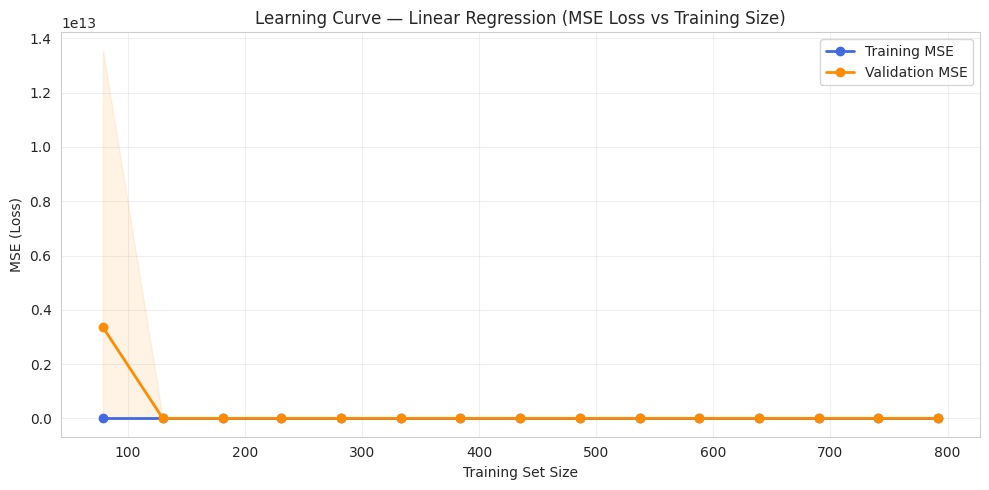

In [20]:
ts, tr_sc, val_sc = learning_curve(
    LinearRegression(), Xs, y_raw, cv=kf,
    scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1,1.0,15), n_jobs=-1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ts, -tr_sc.mean(axis=1),  'o-', color='royalblue',  lw=2, label='Training MSE')
ax.plot(ts, -val_sc.mean(axis=1), 'o-', color='darkorange', lw=2, label='Validation MSE')
ax.fill_between(ts,-tr_sc.min(axis=1),-tr_sc.max(axis=1), alpha=0.1, color='royalblue')
ax.fill_between(ts,-val_sc.min(axis=1),-val_sc.max(axis=1), alpha=0.1, color='darkorange')
ax.set_xlabel('Training Set Size'); ax.set_ylabel('MSE (Loss)')
ax.set_title('Learning Curve — Linear Regression (MSE Loss vs Training Size)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

GridSearch Best params  : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
GridSearch Best CV-RMSE : 307.030 €


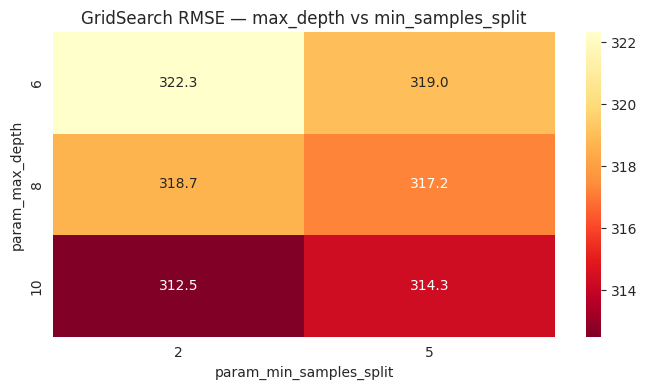

In [21]:
param_grid = {'max_depth':[6,8,10,None],'min_samples_split':[2,5],'min_samples_leaf':[1,2,4]}
gs_dt = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid,
                     cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
gs_dt.fit(X, y_raw)
print(f'GridSearch Best params  : {gs_dt.best_params_}')
print(f'GridSearch Best CV-RMSE : {np.sqrt(-gs_dt.best_score_):.3f} €')

gs_df = pd.DataFrame(gs_dt.cv_results_)
gs_df['rmse'] = np.sqrt(-gs_df['mean_test_score'])
pivot = gs_df.pivot_table('rmse','param_max_depth','param_min_samples_split',aggfunc='mean')
fig, ax = plt.subplots(figsize=(7,4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd_r', ax=ax)
ax.set_title('GridSearch RMSE — max_depth vs min_samples_split')
plt.tight_layout(); plt.show()

In [22]:
rs_gb = RandomizedSearchCV(
    GradientBoostingRegressor(subsample=0.8, random_state=42),
    param_distributions={
        'n_estimators':     randint(500, 1000),
        'learning_rate':    uniform(0.015, 0.04),
        'max_depth':        randint(4, 7),
        'min_samples_leaf': randint(2, 7),
        'max_features':     uniform(0.6, 0.35)
    },
    n_iter=20, cv=5, scoring='r2', random_state=42, n_jobs=-1
)
rs_gb.fit(X, y_log)
print(f'RandomSearch Best Params : {rs_gb.best_params_}')
print(f'RandomSearch Best CV R²  : {rs_gb.best_score_:.4f}')

RandomSearch Best Params : {'learning_rate': np.float64(0.02965447373174767), 'max_depth': 5, 'max_features': np.float64(0.6317122520864873), 'min_samples_leaf': 4, 'n_estimators': 863}
RandomSearch Best CV R²  : 0.9126


In [23]:
best_gb = GradientBoostingRegressor(
    n_estimators    = 800,    
    learning_rate   = 0.025,  
    max_depth       = 5,
    min_samples_leaf= 4,
    subsample       = 0.80,   
    max_features    = 0.75,   
    random_state    = 42
)

print('Training Gradient Boosting with 10-fold CV...')
y_cv_log  = cross_val_predict(best_gb, X, y_log, cv=kf)  
y_cv_pred = np.expm1(y_cv_log)                            

cv_r2   = r2_score(y_raw, y_cv_pred)
cv_rmse = np.sqrt(mean_squared_error(y_raw, y_cv_pred))
cv_mae  = mean_absolute_error(y_raw, y_cv_pred)

print('=' * 55)
print('   GRADIENT BOOSTING v6 — Final CV Results')
print('=' * 55)
print(f'   R²   : {cv_r2:.4f}')
print(f'   RMSE : {cv_rmse:.3f} €')
print(f'   MAE  : {cv_mae:.3f} €')
print('=' * 55)

Training Gradient Boosting with 10-fold CV...
   GRADIENT BOOSTING v6 — Final CV Results
   R²   : 0.9076
   RMSE : 216.167 €
   MAE  : 139.232 €


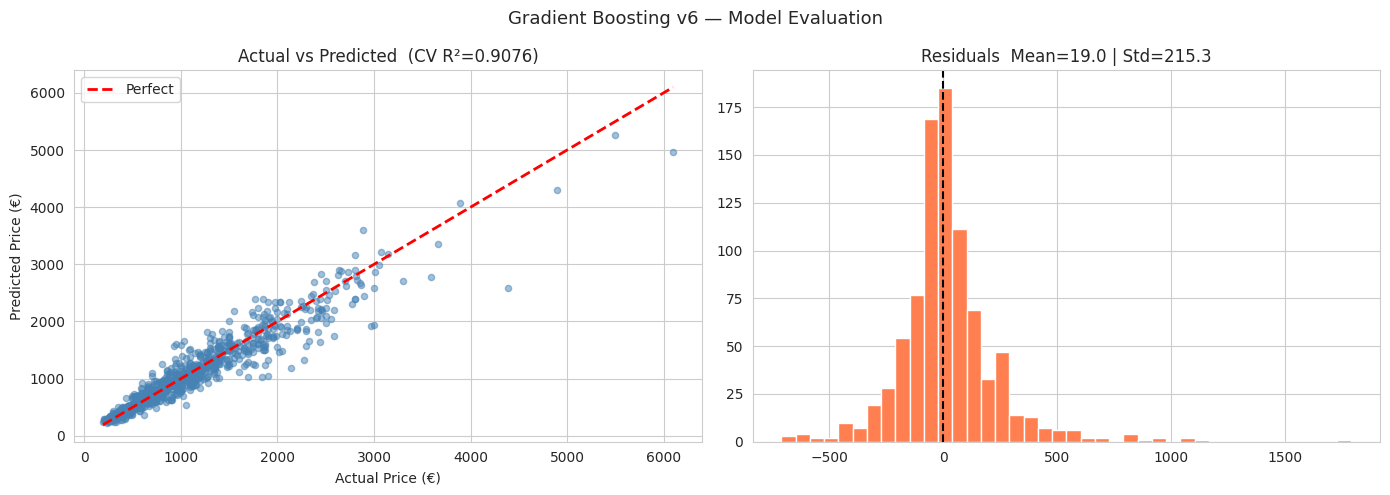

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_raw, y_cv_pred, alpha=0.5, color='steelblue', s=20)
mn, mx = y_raw.min(), y_raw.max()
axes[0].plot([mn,mx],[mn,mx],'r--',lw=2,label='Perfect')
axes[0].set_xlabel('Actual Price (€)'); axes[0].set_ylabel('Predicted Price (€)')
axes[0].set_title(f'Actual vs Predicted  (CV R²={cv_r2:.4f})')
axes[0].legend()
residuals = y_raw - y_cv_pred
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', ls='--')
axes[1].set_title(f'Residuals  Mean={residuals.mean():.1f} | Std={residuals.std():.1f}')
plt.suptitle('Gradient Boosting v6 — Model Evaluation', fontsize=13)
plt.tight_layout(); plt.show()

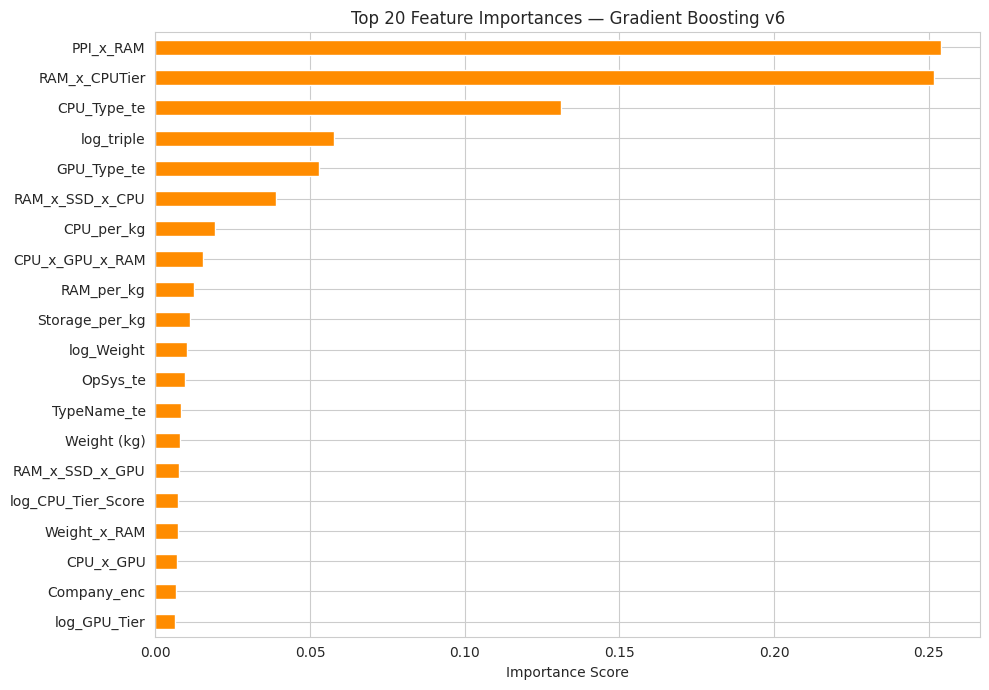

In [25]:
best_gb.fit(X, y_log)
imp = pd.Series(best_gb.feature_importances_, index=feature_cols)
imp = imp.sort_values(ascending=True).tail(20)
fig, ax = plt.subplots(figsize=(10, 7))
imp.plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
ax.set_title('Top 20 Feature Importances — Gradient Boosting v6')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.show()

In [26]:
names  = ['Linear\nRegression','Ridge','Lasso','Decision\nTree','Polynomial\n(deg=30)','GB v6\n(Improved)']
r2_all = [
    cross_val_score(LinearRegression(), Xs, y_raw, cv=kf, scoring='r2').mean(),
    cross_val_score(Ridge(alpha=10), Xs, y_raw, cv=kf, scoring='r2').mean(),
    cross_val_score(Lasso(alpha=1,max_iter=10000), Xs, y_raw, cv=kf, scoring='r2').mean(),
    cross_val_score(DecisionTreeRegressor(max_depth=8,random_state=42), X, y_raw, cv=kf, scoring='r2').mean(),
    cross_val_score(Pipeline([('p',PolynomialFeatures(30,include_bias=False)),('r',Ridge(1e4))]),
                    Xp, y_raw, cv=kf, scoring='r2').mean(),
    cv_r2
]

colors = ['#27ae60' if v==max(r2_all) else '#3498db' if v>0.80 else '#95a5a6' for v in r2_all]
fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(names, r2_all, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, r2_all):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
ax.axhline(0.760, color='red',    ls='--', lw=2, label='v2 Kaggle (0.760)')
ax.axhline(0.780, color='orange', ls='--', lw=2, label='v3 Kaggle (0.780)')
ax.set_ylabel('R² Score'); ax.set_ylim(0, 1.05)
ax.set_title('All Models — R² vs Previous Kaggle Scores')
ax.legend(); plt.tight_layout(); plt.show()

TypeError: __init__(): incompatible constructor arguments. The following argument types are supported:
    1. matplotlib.backends._backend_agg.RendererAgg(width: int, height: int, dpi: float)

Invoked with: 1078, 69400258406, 100.0

<Figure size 1300x500 with 1 Axes>

In [27]:
# Retrain on full data, predict test set
best_gb.fit(X, y_log)
test_preds = np.expm1(best_gb.predict(X_test))

submission = pd.DataFrame({
    'id':           test['id'],
    'Price (Euro)': test_preds
})
submission.to_csv('submission.csv', index=False)

print(f'✅ submission.csv saved')
print(f'   Columns : {list(submission.columns)}')
print(f'   Rows    : {len(submission)}')
print(f'   Model   : Gradient Boosting v6 (800 trees, lr=0.025, 99 features)')
print(f'   CV R²   : {cv_r2:.4f}')
print(f'   CV RMSE : {cv_rmse:.3f} €')
print(f'   CV MAE  : {cv_mae:.3f} €')
submission.head(10)

✅ submission.csv saved
   Columns : ['id', 'Price (Euro)']
   Rows    : 394
   Model   : Gradient Boosting v6 (800 trees, lr=0.025, 99 features)
   CV R²   : 0.9076
   CV RMSE : 216.167 €
   CV MAE  : 139.232 €


,id,Price (Euro)
0,882,720.037751
1,883,297.372039
2,884,917.570084
3,885,315.011214
4,886,1672.493705
5,887,504.099235
6,888,1145.425097
7,889,327.583061
8,890,537.498971
9,891,734.604016
